In [2]:
from src import *
from myutils import *

In [3]:
root = r'h:\noisy\20241110'

In [6]:
# for duty in np.arange(0, 101, 10):
#     raw = np.load(os.path.join(root, f'di_0.2_raw_{duty}.npy'))
#     timestamp = np.load(os.path.join(root, f'di_0.2_timestamp_{duty}.npy'))

#     meta = MetaData('DI', 0.2, 5*DMD.PIXEL_SIZE/2, timestamp)

#     c = FrequencyEstimation.FromRaw(raw, meta)

#     c.savez(f'__estimates__/noisy/di_0.2_{duty}.npz')

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 400.

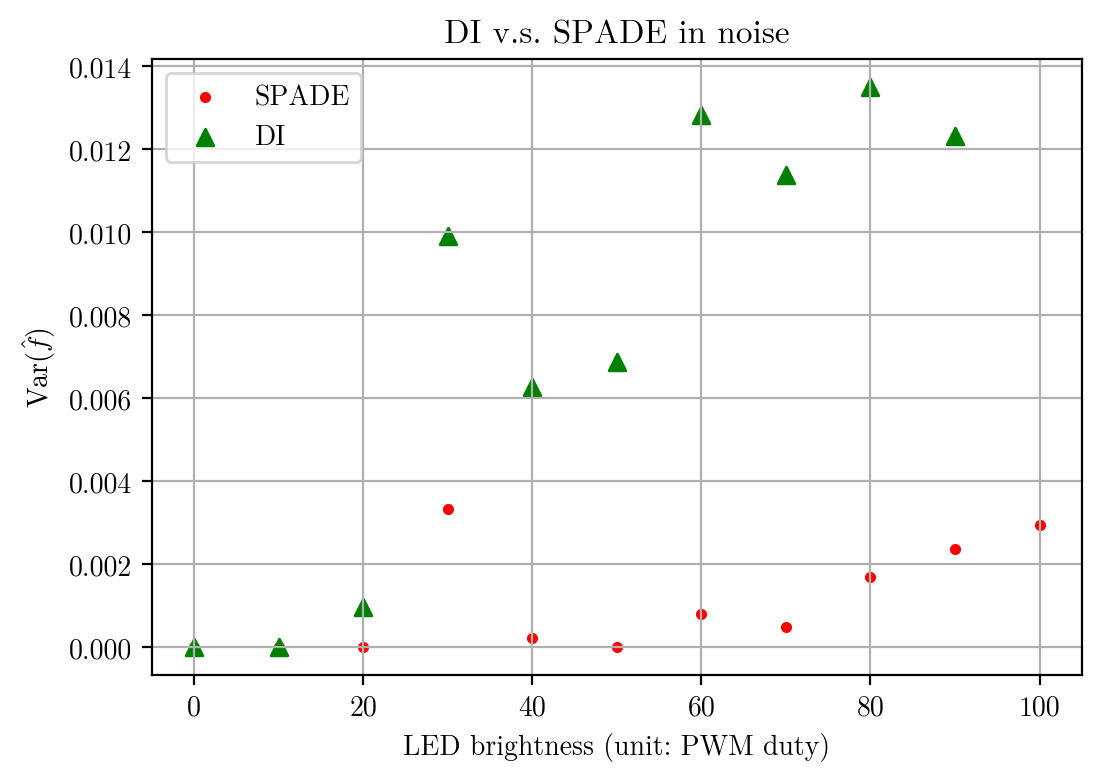

In [11]:
di_pn = LoadEstimates(f'__estimates__/noisy/di_0.2_0.npz').photons.mean()
spade_pn = LoadEstimates(f'__estimates__/noisy/spade_0.2_0.npz').photons.mean()

di_y, spade_y = [], []

for duty in np.arange(0, 100, 10):
    for m in ('spade', 'di'):
        c = LoadEstimates(f'__estimates__/noisy/{m}_0.2_{duty}.npz')
        if m == 'spade':
            spade_y.append(c.frequency_estimates.var(ddof=1) * 1)

        if m == 'di':
            di_y.append(c.frequency_estimates.var(ddof=1) * 1)

c = LoadEstimates(f'__estimates__/noisy/spade_0.2_100.npz')
spade_y.append(c.frequency_estimates.var(ddof=1) * 1)

scatter(np.arange(0, 101, 10), spade_y, c='r', marker='.', label='SPADE')
scatter(np.arange(0, 100, 10), di_y, c='g', marker='^', label='DI')

# plot(ylim=(-0.0001, 0.0001))
plt.xlabel('LED brightness (unit: PWM duty)')
plt.ylabel(r'${\rm Var}(\hat f)$')
plt.title('DI v.s. SPADE in noise')
plt.show()

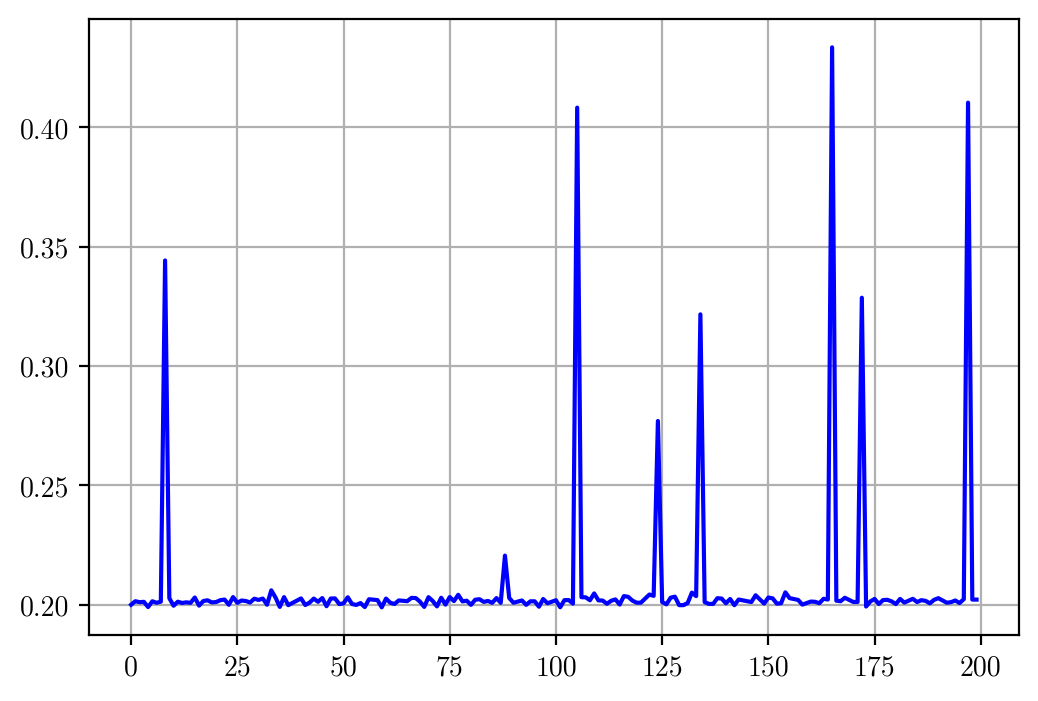

In [30]:
c = LoadEstimates(f'__estimates__/noisy/di_0.2_20.npz')
plot(c.frequency_estimates)

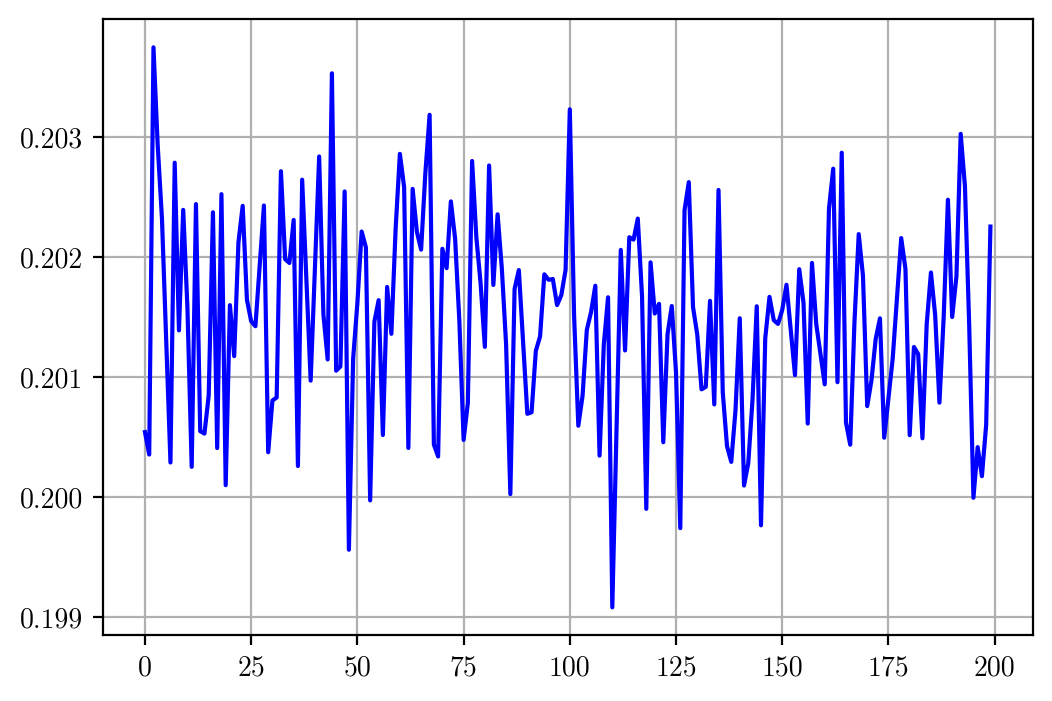

In [26]:
plot(c.frequency_estimates)